In [18]:
import pandas as pd


## Analysing Customer Behaviour

In [19]:
data=pd.read_csv('..\data\cleaned_sales_data.csv')


In [20]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])

### Number of distinct orders placed by each customer

In [21]:
orders_per_customer = data.groupby('CustomerID')['InvoiceNo'].nunique()
print(orders_per_customer.sort_values(ascending=False).head())

CustomerID
12748    209
14911    201
17841    124
13089     97
14606     93
Name: InvoiceNo, dtype: int64


### Top 5 Customers who have the highest Expense

In [22]:
customer_revenue= data.groupby('CustomerID')['Revenue'].sum()
print(customer_revenue.sort_values(ascending=False).head(5))

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
Name: Revenue, dtype: float64


### Top Customers who have the highest Expense and total number of Oders made by them

In [23]:
customer_summary= data.groupby('CustomerID').agg({
    
    'InvoiceNo':'nunique',
    'Revenue':'sum'
}).rename(columns={
    'InvoiceNo': 'TotalOrders',
    'Revenue': 'TotalRevenue'})
print(customer_summary.sort_values(by='TotalRevenue', ascending=False).head())

            TotalOrders  TotalRevenue
CustomerID                           
14646                73     280206.02
18102                60     259657.30
17450                46     194390.79
16446                 2     168472.50
14911               201     143711.17


### Top Customers with highest orders and their expense

In [24]:
customer_summary= data.groupby('CustomerID').agg({
    
    'InvoiceNo':'nunique',
    'Revenue':'sum'
}).rename(columns={
    'InvoiceNo': 'TotalOrders',
    'Revenue': 'TotalRevenue'})
print(customer_summary.sort_values(by='TotalOrders', ascending=False).head())

            TotalOrders  TotalRevenue
CustomerID                           
12748               209      33053.19
14911               201     143711.17
17841               124      40519.84
13089                97      58762.08
14606                93      12076.15


### Monthly revenue


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392451 entries, 0 to 392450
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392451 non-null  int64         
 1   StockCode    392451 non-null  object        
 2   Description  392451 non-null  object        
 3   Quantity     392451 non-null  int64         
 4   InvoiceDate  392451 non-null  datetime64[ns]
 5   UnitPrice    392451 non-null  float64       
 6   CustomerID   392451 non-null  int64         
 7   Country      392451 non-null  object        
 8   Revenue      392451 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 26.9+ MB


In [26]:
data['Month'] = data['InvoiceDate'].dt.to_period('M')


In [27]:
monthly_revenue = data.groupby('Month')['Revenue'].sum()

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

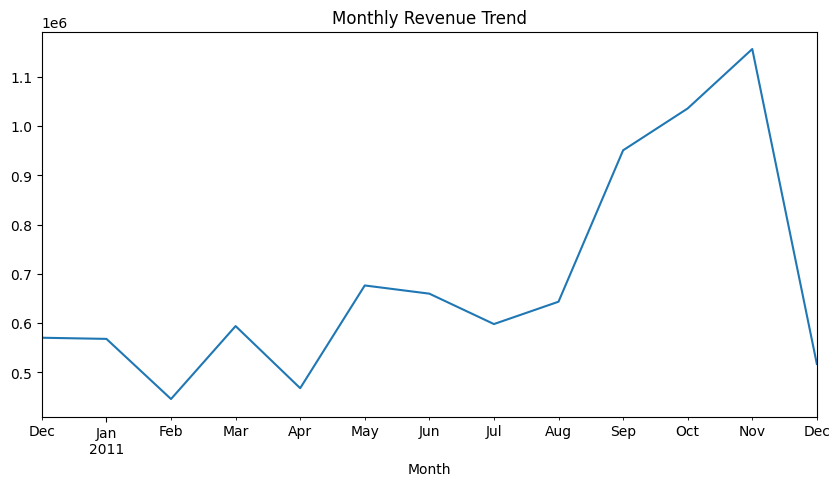

In [28]:

monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")



### Top selling products

In [29]:
top_products = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142239.25
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56375.85
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


### Revenue by Country

In [30]:
country_sales = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

print(country_sales.head(10))

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


### Top Customers

In [31]:
top_customers = data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64


### Average Order Value

In [32]:
avg_order_value = data.groupby('InvoiceNo')['Revenue'].sum().mean()

print("Average Order Value:", avg_order_value)

Average Order Value: 479.62363010148994


## validate stock codes and description consistency

### 1. IDENTIFY NON-STANDARD STOCK CODES

In [33]:
non_standard_codes = data[
    data['StockCode'].str.contains('^[A-Za-z]+$', regex=True, na=False)
]['StockCode'].unique()

print("Non-standard StockCodes (purely alphabetical):")
print(non_standard_codes)


Non-standard StockCodes (purely alphabetical):
['POST' 'M' 'PADS' 'DOT']


### 2. CHECK DESCRIPTIONS FOR THESE CODES


In [34]:

print("\nDescriptions for non-standard codes:\n")

for code in non_standard_codes:
    desc = data[data['StockCode'] == code]['Description'].unique()
    print(f"{code}: {desc}")



Descriptions for non-standard codes:

POST: ['POSTAGE']
M: ['Manual']
PADS: ['PADS TO MATCH ALL CUSHIONS']
DOT: ['DOTCOM POSTAGE']


### 3. STOCKCODE → DESCRIPTION CONSISTENCY

In [36]:


stockcode_desc_counts = data.groupby('StockCode')['Description'].nunique()

codes_with_multiple_descs = stockcode_desc_counts[stockcode_desc_counts > 1]

print(f"\nNumber of StockCodes with >1 Description: {len(codes_with_multiple_descs)}")

if len(codes_with_multiple_descs) > 0:
    print("\nExample StockCode with multiple descriptions:")
    example_code = codes_with_multiple_descs.index[0]
    print(f"Code {example_code}:",
          data[data['StockCode'] == example_code]['Description'].unique())


Number of StockCodes with >1 Description: 213

Example StockCode with multiple descriptions:
Code 16156L: ['WRAP, CAROUSEL' 'WRAP CAROUSEL']



### 4. DESCRIPTION → STOCKCODE CHECK


In [38]:
desc_stockcode_counts = data.groupby('Description')['StockCode'].nunique()

descs_with_multiple_codes = desc_stockcode_counts[desc_stockcode_counts > 1]

print("\nNumber of Descriptions with >1 StockCode:", len(descs_with_multiple_codes))


Number of Descriptions with >1 StockCode: 19


## Top Selling Products Analysis

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142239.25
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56375.85
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


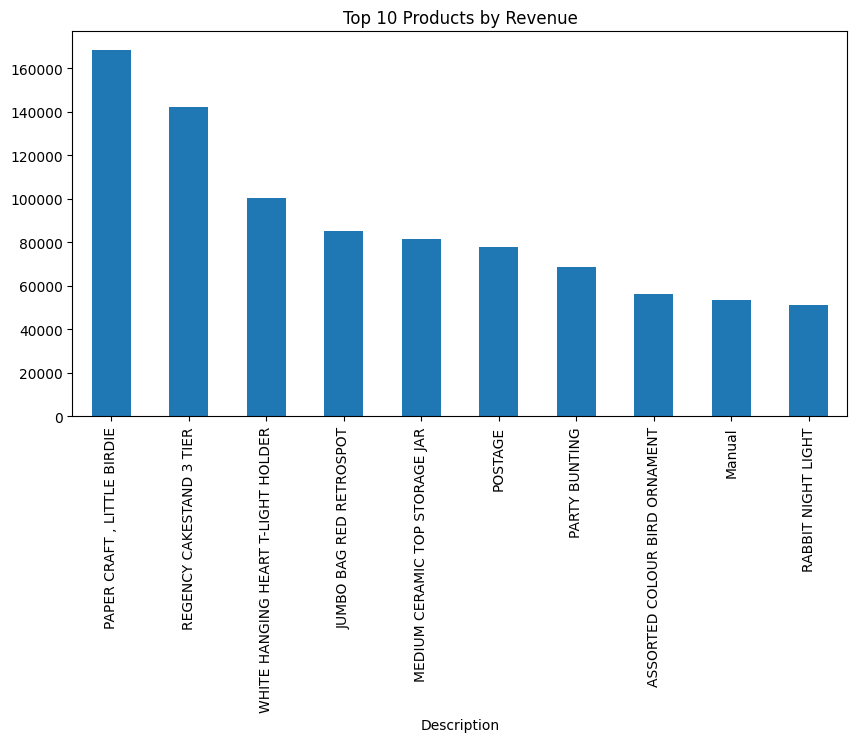

In [40]:
top_products = data.groupby('Description')['Revenue'].sum() \
                   .sort_values(ascending=False).head(10)

print(top_products)

top_products.plot(kind='bar', figsize=(10,5), title="Top 10 Products by Revenue")
plt.show()

In [47]:
import seaborn as sns


C:\Users\Betina Kuriakose\AppData\Local\Temp\ipykernel_14760\520508755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


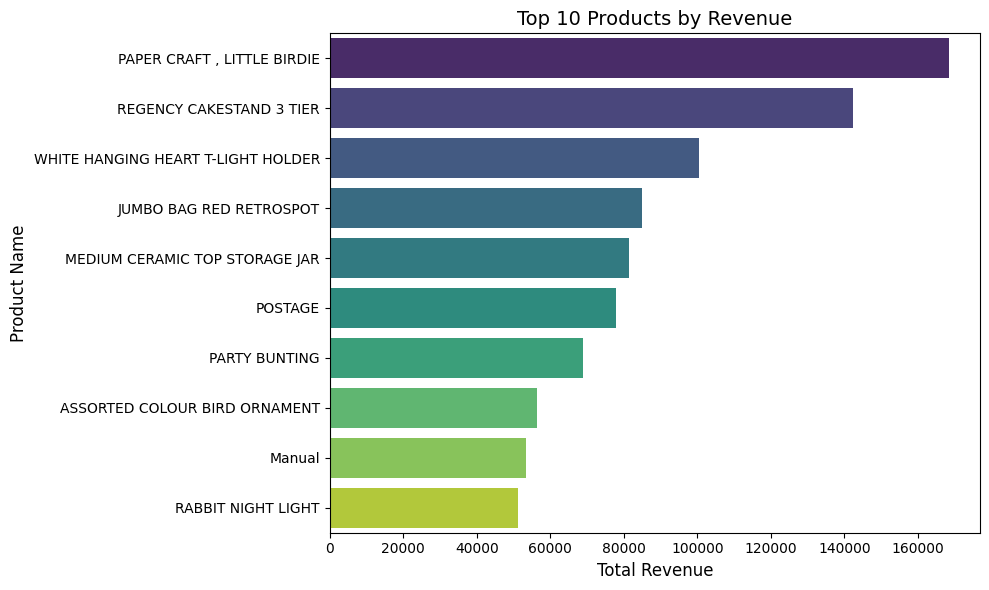

In [48]:
top_products = data.groupby('Description')['Revenue'].sum() \
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

## Country Analysis

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


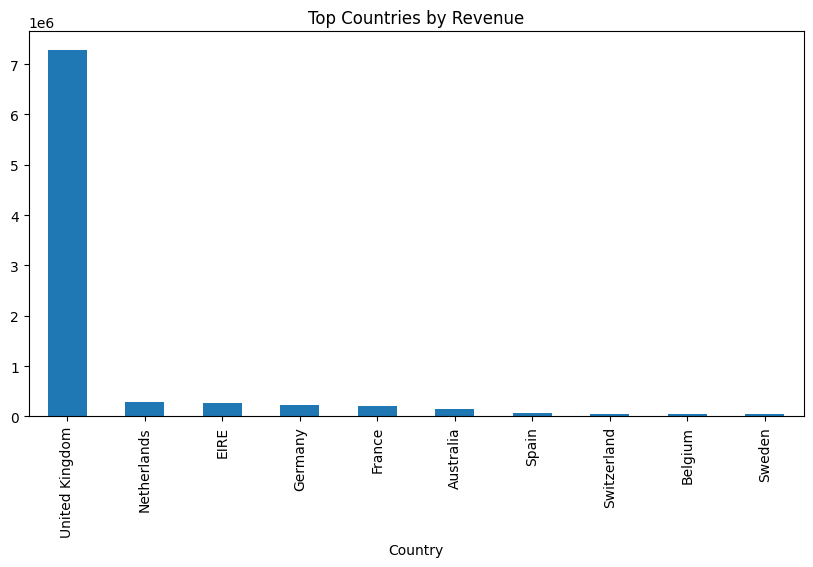

In [41]:
country_sales = data.groupby('Country')['Revenue'].sum() \
                   .sort_values(ascending=False)

print(country_sales.head(10))

country_sales.head(10).plot(kind='bar', figsize=(10,5), title="Top Countries by Revenue")
plt.show()

## Customer Analysis

In [42]:
top_customers = data.groupby('CustomerID')['Revenue'].sum() \
                    .sort_values(ascending=False).head(10)

print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64


### Orders per customer

In [43]:
orders_per_customer = data.groupby('CustomerID')['InvoiceNo'].nunique()

print(orders_per_customer.describe())

count    4334.000000
mean        4.274112
std         7.701241
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


### Average Order Value

In [44]:
avg_order_value = data.groupby('InvoiceNo')['Revenue'].sum().mean()

print("Average Order Value:", avg_order_value)

Average Order Value: 479.62363010148994


### Most customers buy small quantities
### Few bulk buyers → long tail

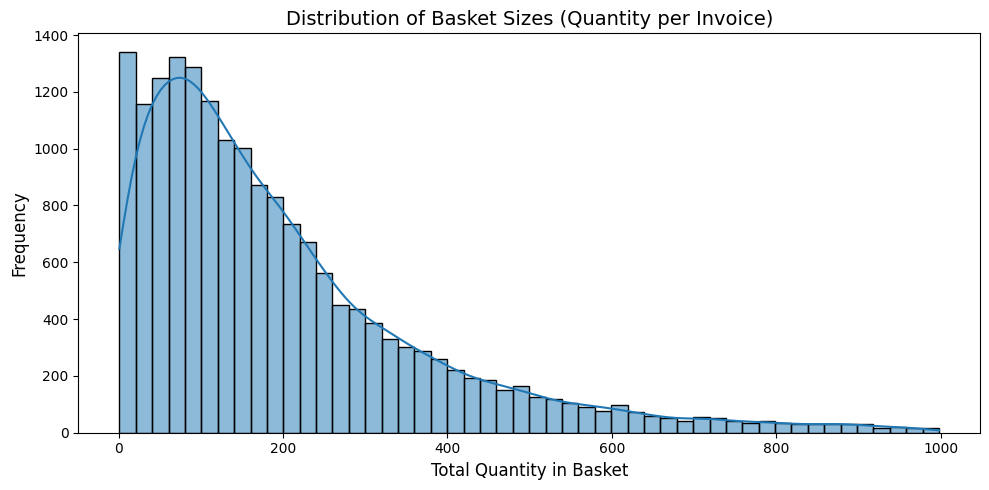

In [50]:
basket_sizes = data.groupby('InvoiceNo')['Quantity'].sum()

# remove extreme outliers for better visualization
filtered_basket = basket_sizes[basket_sizes < 1000]

plt.figure(figsize=(10, 5))
sns.histplot(filtered_basket, bins=50, kde=True)
plt.title('Distribution of Basket Sizes (Quantity per Invoice)', fontsize=14)
plt.xlabel('Total Quantity in Basket', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()